# CNN - VNINDEX

## Descriptions
1. Features: ["sma_"]
1. Target: "return_5"
1. Timeshift: 30
1. Forecast horizon: 5
1. Remove dayoffs

## Deploy TensorBoard

In [250]:
# tensorboard --logdir=src/model/lightning_logs/

## Import libraries

In [251]:
import os
import sys
from datetime import datetime, timedelta
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tsfresh.utilities.dataframe_functions import (
    roll_time_series,
)
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters, EfficientFCParameters
import matplotlib.pylab as plt
from sklearn.preprocessing import MinMaxScaler
from lightning.pytorch.callbacks import EarlyStopping
from dataclasses import asdict
import ipynbname
from sklearn.inspection import permutation_importance
import xgboost as xgb
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import FEATURE_SELECTION_LOG_FILE_BASE
from dtos.config_dtos.config_dto import ConfigDto
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from utils.enums import (
    LossFunctionType,
    ModelAchitectureType,
    OptimizerType,
    ScalerType,
)
from ta.ta_functions import *

## Helper functions

In [252]:
def get_weekends(from_date: str, to_date: str):
    start = datetime.strptime(from_date, "%Y-%m-%d")
    end = datetime.strptime(to_date, "%Y-%m-%d")

    weekends = []
    current = start

    while current <= end:
        if current.weekday() in (5, 6):  # 5 = Saturday, 6 = Sunday
            weekends.append(current.strftime("%Y-%m-%d"))
        current += timedelta(days=1)

    return weekends

## Parameters

In [253]:
NOTEBOOK_NAME = ipynbname.name()
RANDOM_SEED = 18
MAX_TIMESHIFT = 5
MIN_TIMESHIFT = 5
FORECAST_HORIZON = 5
COLUMN_ID = "stock"
TARGET_COLUMN = "return_5"
DATE_COLUMN = "date"
FEATURE_COLUMNS = []  # all TA indicators

# Inclusive
TRAIN_RANGE = ("2000-01-01", "2021-12-31")
VALIDATION_RANGE = ("2022-01-01", "2023-12-31")
TEST_RANGE = ("2024-01-01", "2026-02-26")

OUTPUT_SIZE = 1

In [254]:
WEEKENDS = get_weekends(TRAIN_RANGE[0], TEST_RANGE[1])
HOLIDAYS = []

DAYOFFS = []
DAYOFFS.extend(WEEKENDS)
DAYOFFS.extend(HOLIDAYS)

DAYOFFS[:10], DAYOFFS[-10:]

(['2000-01-01',
  '2000-01-02',
  '2000-01-08',
  '2000-01-09',
  '2000-01-15',
  '2000-01-16',
  '2000-01-22',
  '2000-01-23',
  '2000-01-29',
  '2000-01-30'],
 ['2026-01-24',
  '2026-01-25',
  '2026-01-31',
  '2026-02-01',
  '2026-02-07',
  '2026-02-08',
  '2026-02-14',
  '2026-02-15',
  '2026-02-21',
  '2026-02-22'])

## Hyper Parameters

In [255]:
MAX_EPOCHS = 3000
LEARNING_RATE = 1.0e-05
PATIENCE = 100
BATCH_SIZE = 128

In [256]:
MODEL_PARAMS = {"remove_dayoffs": True}
MODEL_PARAMS

{'remove_dayoffs': True}

## Start

### Get data

In [257]:
my_logger = Logger(file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/vn_index/test")

In [258]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [259]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [260]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [261]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "adjust": float,
    "change": float,
    "percent_change": float,
    "matching_volume": float,
    "matching_value": float,
    "negotiate_volume": float,
    "negotiate_value": float,
    "number_of_buy_orders": float,
    "buy_volume": float,
    "average_volume_per_buy_order": float,
    "number_of_sell_orders": float,
    "sell_volume": float,
    "average_volume_per_sell_order": float,
    "net_volume": float,
}

vn_index_df = (
    vn_index_df.astype(dtype_map)
    .dropna(subset=["close"])
    .sort_values(by=["date"])
    .reset_index(drop=True)
)

In [262]:
vn_index_df

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,negotiate_value,number_of_buy_orders,buy_volume,average_volume_per_buy_order,number_of_sell_orders,sell_volume,average_volume_per_sell_order,net_volume
0,2008-03-07,640.140,640.140,640.140,640.140,640.140,28.970000,4.740000,8.169220e+06,5.152538e+11,350040.0,2.910304e+10,26816.0,5.268141e+07,1965.000000,3448.0,9.057040e+06,2627.0,4.362437e+07
1,2008-03-08,646.190,646.190,646.190,646.190,646.190,25.363333,4.106667,1.314382e+07,8.298321e+11,769057.0,4.594466e+10,27442.0,5.068024e+07,1852.333333,7486.0,1.712815e+07,2464.0,3.355209e+07
2,2008-03-09,652.240,652.240,652.240,652.240,652.240,21.756667,3.473333,1.811842e+07,1.144410e+12,1188073.0,6.278627e+10,28068.0,4.867907e+07,1739.666667,11523.0,2.519927e+07,2301.0,2.347980e+07
3,2008-03-10,658.290,658.290,658.290,658.290,658.290,18.150000,2.840000,2.309302e+07,1.458989e+12,1607090.0,7.962789e+10,28694.0,4.667790e+07,1627.000000,15561.0,3.327038e+07,2138.0,1.340752e+07
4,2008-03-11,638.710,638.710,638.710,638.710,638.710,-19.580000,-2.970000,1.384280e+07,8.374665e+11,226000.0,1.209960e+10,14464.0,1.933131e+07,1337.000000,17910.0,2.811427e+07,1570.0,-8.782960e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6561,2026-02-22,1832.317,1859.236,1829.801,1856.535,1856.535,33.445000,1.837000,7.158068e+08,2.227241e+13,23581058.0,7.924402e+11,476711.0,1.233848e+09,2591.300000,393692.0,1.198445e+09,3047.9,3.540296e+07
6562,2026-02-23,1833.900,1863.130,1833.900,1860.140,1860.140,36.050000,1.980000,7.313611e+08,2.264621e+13,23192200.0,7.774309e+11,486603.0,1.253004e+09,2575.000000,401281.0,1.213944e+09,3025.0,3.906029e+07
6563,2026-02-24,1862.180,1867.690,1849.600,1867.620,1867.620,7.480000,0.400000,9.667547e+08,3.120594e+13,22413147.0,7.795734e+11,598087.0,1.575227e+09,2634.000000,507471.0,1.648273e+09,3248.0,-7.304628e+07
6564,2026-02-25,1869.490,1876.010,1855.890,1860.910,1860.910,-6.710000,-0.360000,1.083635e+09,3.567852e+13,62225450.0,1.856894e+12,694266.0,1.862364e+09,2682.000000,597096.0,1.892734e+09,3170.0,-3.036983e+07


### Data transformation

#### Remove DAYOFFS

In [263]:
vn_index_df_t1 = vn_index_df[~vn_index_df["date"].isin(DAYOFFS)]
vn_index_df_t1.shape

(4690, 19)

#### Calculate log return

In [264]:
vn_index_df_t2 = vn_index_df_t1.copy()
vn_index_df_t2[f"return_{FORECAST_HORIZON}"] = (
    vn_index_df_t2["close"].shift(-FORECAST_HORIZON) - vn_index_df_t1["close"]
)
# vn_index_df_t2[f"log_return_{FORECAST_HORIZON}"] = np.log(
#     vn_index_df_t2["close"].shift(-FORECAST_HORIZON) / vn_index_df_t2["close"]
# )
vn_index_df_t2 = vn_index_df_t2.dropna(how="any").reset_index(drop=True)
vn_index_df_t2

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,negotiate_value,number_of_buy_orders,buy_volume,average_volume_per_buy_order,number_of_sell_orders,sell_volume,average_volume_per_sell_order,net_volume,return_5
0,2008-03-07,640.140,640.140,640.140,640.140,640.140,28.970,4.740,8169220.0,5.152538e+11,350040.0,2.910304e+10,26816.0,5.268141e+07,1965.0,3448.0,9.057040e+06,2627.0,43624370.0,3.660
1,2008-03-10,658.290,658.290,658.290,658.290,658.290,18.150,2.840,23093020.0,1.458989e+12,1607090.0,7.962789e+10,28694.0,4.667790e+07,1627.0,15561.0,3.327038e+07,2138.0,13407520.0,-42.580
2,2008-03-11,638.710,638.710,638.710,638.710,638.710,-19.580,-2.970,13842800.0,8.374665e+11,226000.0,1.209960e+10,14464.0,1.933131e+07,1337.0,17910.0,2.811427e+07,1570.0,-8782960.0,-50.450
3,2008-03-12,643.900,643.900,643.900,643.900,643.900,5.190,0.810,12166910.0,7.659728e+11,290070.0,2.036917e+10,16836.0,2.378011e+07,1412.0,12032.0,2.034621e+07,1691.0,3433900.0,-70.450
4,2008-03-13,647.600,647.600,647.600,647.600,647.600,3.700,0.570,8930090.0,5.844466e+11,289160.0,1.702626e+10,13298.0,1.703506e+07,1281.0,12256.0,1.900562e+07,1551.0,-1970560.0,-82.780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4680,2026-02-13,1818.070,1824.190,1792.910,1824.090,1824.090,10.000,0.550,575818400.0,1.890820e+13,27080782.0,9.275247e+11,387678.0,1.061450e+09,2738.0,325388.0,1.058963e+09,3254.0,2486986.0,25.235
4681,2026-02-16,1822.819,1835.872,1805.207,1834.905,1834.905,17.815,0.979,622481210.0,2.002960e+13,25914207.0,8.824965e+11,417356.0,1.118916e+09,2689.1,348156.0,1.105457e+09,3185.3,13458978.0,25.235
4682,2026-02-17,1824.402,1839.766,1809.306,1838.510,1838.510,20.420,1.122,638035480.0,2.040340e+13,25525349.0,8.674871e+11,427248.0,1.138071e+09,2672.8,355745.0,1.120955e+09,3162.4,17116309.0,29.110
4683,2026-02-18,1825.985,1843.660,1813.405,1842.115,1842.115,23.025,1.265,653589750.0,2.077720e+13,25136491.0,8.524778e+11,437141.0,1.157227e+09,2656.5,363335.0,1.136453e+09,3139.5,20773640.0,18.795


#### Create features

In [265]:
vn_index_df_t3 = add_one_for_all_ta(vn_index_df_t2)
vn_index_df_t3 = add_sma(vn_index_df_t2, n=[5, 10, 15])
# vn_index_df_t3 = vn_index_df_t2

In [266]:
FEATURE_COLUMNS = list(
    vn_index_df_t3.columns.drop(
        [
            DATE_COLUMN,
            TARGET_COLUMN,
            # "open",
            # "high",
            # "low",
            # "adjust",
            # "change",
            # "percent_change",
            # "matching_volume",
            # "matching_value",
            # "negotiate_volume",
            # "negotiate_value",
            # "close",
            # "number_of_buy_orders",
            # "buy_volume",
        ]
    )
)
FEATURE_COLUMNS

['open',
 'high',
 'low',
 'close',
 'adjust',
 'change',
 'percent_change',
 'matching_volume',
 'matching_value',
 'negotiate_volume',
 'negotiate_value',
 'number_of_buy_orders',
 'buy_volume',
 'average_volume_per_buy_order',
 'number_of_sell_orders',
 'sell_volume',
 'average_volume_per_sell_order',
 'net_volume',
 'close_sma_5',
 'close_sma_5_slope',
 'close_sma_10',
 'close_sma_10_slope',
 'close_sma_15',
 'close_sma_15_slope',
 'close_sma_5_10_dist',
 'close_sma_5_15_dist',
 'close_sma_10_15_dist']

In [267]:
vn_index_df_final = vn_index_df_t3[[DATE_COLUMN] + FEATURE_COLUMNS + [TARGET_COLUMN]]
vn_index_df_final

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,...,close_sma_5,close_sma_5_slope,close_sma_10,close_sma_10_slope,close_sma_15,close_sma_15_slope,close_sma_5_10_dist,close_sma_5_15_dist,close_sma_10_15_dist,return_5
0,2008-03-07,640.140,640.140,640.140,640.140,640.140,28.970,4.740,8169220.0,5.152538e+11,...,640.140000,NaN,640.140000,NaN,640.140000,NaN,0.0000,0.000000,0.000000,3.660
1,2008-03-10,658.290,658.290,658.290,658.290,658.290,18.150,2.840,23093020.0,1.458989e+12,...,649.215000,9.075000,649.215000,9.075000,649.215000,9.075000,0.0000,0.000000,0.000000,-42.580
2,2008-03-11,638.710,638.710,638.710,638.710,638.710,-19.580,-2.970,13842800.0,8.374665e+11,...,645.713333,-3.501667,645.713333,-3.501667,645.713333,-3.501667,0.0000,0.000000,0.000000,-50.450
3,2008-03-12,643.900,643.900,643.900,643.900,643.900,5.190,0.810,12166910.0,7.659728e+11,...,645.260000,-0.453333,645.260000,-0.453333,645.260000,-0.453333,0.0000,0.000000,0.000000,-70.450
4,2008-03-13,647.600,647.600,647.600,647.600,647.600,3.700,0.570,8930090.0,5.844466e+11,...,645.728000,0.468000,645.728000,0.468000,645.728000,0.468000,0.0000,0.000000,0.000000,-82.780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4680,2026-02-13,1818.070,1824.190,1792.910,1824.090,1824.090,10.000,0.550,575818400.0,1.890820e+13,...,1788.776000,13.720000,1789.326000,-0.495000,1800.960667,-3.113333,-0.5500,-12.184667,-11.634667,25.235
4681,2026-02-16,1822.819,1835.872,1805.207,1834.905,1834.905,17.815,0.979,622481210.0,2.002960e+13,...,1804.793000,16.017000,1792.166500,2.840500,1800.373000,-0.587667,12.6265,4.420000,-8.206500,25.235
4682,2026-02-17,1824.402,1839.766,1809.306,1838.510,1838.510,20.420,1.122,638035480.0,2.040340e+13,...,1821.689000,16.896000,1794.677500,2.511000,1800.907000,0.534000,27.0115,20.782000,-6.229500,29.110
4683,2026-02-18,1825.985,1843.660,1813.405,1842.115,1842.115,23.025,1.265,653589750.0,2.077720e+13,...,1830.742000,9.053000,1799.746000,5.068500,1803.520667,2.613667,30.9960,27.221333,-3.774667,18.795


In [268]:
vn_index_df_final.loc[:, "stock"] = "vn_index"
vn_index_df_final

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21024\1961083148.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vn_index_df_final.loc[:, "stock"] = "vn_index"


,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,...,close_sma_5_slope,close_sma_10,close_sma_10_slope,close_sma_15,close_sma_15_slope,close_sma_5_10_dist,close_sma_5_15_dist,close_sma_10_15_dist,return_5,stock
0,2008-03-07,640.140,640.140,640.140,640.140,640.140,28.970,4.740,8169220.0,5.152538e+11,...,NaN,640.140000,NaN,640.140000,NaN,0.0000,0.000000,0.000000,3.660,vn_index
1,2008-03-10,658.290,658.290,658.290,658.290,658.290,18.150,2.840,23093020.0,1.458989e+12,...,9.075000,649.215000,9.075000,649.215000,9.075000,0.0000,0.000000,0.000000,-42.580,vn_index
2,2008-03-11,638.710,638.710,638.710,638.710,638.710,-19.580,-2.970,13842800.0,8.374665e+11,...,-3.501667,645.713333,-3.501667,645.713333,-3.501667,0.0000,0.000000,0.000000,-50.450,vn_index
3,2008-03-12,643.900,643.900,643.900,643.900,643.900,5.190,0.810,12166910.0,7.659728e+11,...,-0.453333,645.260000,-0.453333,645.260000,-0.453333,0.0000,0.000000,0.000000,-70.450,vn_index
4,2008-03-13,647.600,647.600,647.600,647.600,647.600,3.700,0.570,8930090.0,5.844466e+11,...,0.468000,645.728000,0.468000,645.728000,0.468000,0.0000,0.000000,0.000000,-82.780,vn_index
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4680,2026-02-13,1818.070,1824.190,1792.910,1824.090,1824.090,10.000,0.550,575818400.0,1.890820e+13,...,13.720000,1789.326000,-0.495000,1800.960667,-3.113333,-0.5500,-12.184667,-11.634667,25.235,vn_index
4681,2026-02-16,1822.819,1835.872,1805.207,1834.905,1834.905,17.815,0.979,622481210.0,2.002960e+13,...,16.017000,1792.166500,2.840500,1800.373000,-0.587667,12.6265,4.420000,-8.206500,25.235,vn_index
4682,2026-02-17,1824.402,1839.766,1809.306,1838.510,1838.510,20.420,1.122,638035480.0,2.040340e+13,...,16.896000,1794.677500,2.511000,1800.907000,0.534000,27.0115,20.782000,-6.229500,29.110,vn_index
4683,2026-02-18,1825.985,1843.660,1813.405,1842.115,1842.115,23.025,1.265,653589750.0,2.077720e+13,...,9.053000,1799.746000,5.068500,1803.520667,2.613667,30.9960,27.221333,-3.774667,18.795,vn_index


In [269]:
vn_index_df_final = vn_index_df_final.dropna(how="any")
vn_index_df_final.shape

(4684, 30)

In [270]:
input_df = vn_index_df_final
input_df

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,...,close_sma_5_slope,close_sma_10,close_sma_10_slope,close_sma_15,close_sma_15_slope,close_sma_5_10_dist,close_sma_5_15_dist,close_sma_10_15_dist,return_5,stock
1,2008-03-10,658.290,658.290,658.290,658.290,658.290,18.150,2.840,23093020.0,1.458989e+12,...,9.075000,649.215000,9.075000,649.215000,9.075000,0.000000,0.000000,0.000000,-42.580,vn_index
2,2008-03-11,638.710,638.710,638.710,638.710,638.710,-19.580,-2.970,13842800.0,8.374665e+11,...,-3.501667,645.713333,-3.501667,645.713333,-3.501667,0.000000,0.000000,0.000000,-50.450,vn_index
3,2008-03-12,643.900,643.900,643.900,643.900,643.900,5.190,0.810,12166910.0,7.659728e+11,...,-0.453333,645.260000,-0.453333,645.260000,-0.453333,0.000000,0.000000,0.000000,-70.450,vn_index
4,2008-03-13,647.600,647.600,647.600,647.600,647.600,3.700,0.570,8930090.0,5.844466e+11,...,0.468000,645.728000,0.468000,645.728000,0.468000,0.000000,0.000000,0.000000,-82.780,vn_index
5,2008-03-14,643.800,643.800,643.800,643.800,643.800,-3.800,-0.590,8379060.0,5.438243e+11,...,0.732000,645.406667,-0.321333,645.406667,-0.321333,1.053333,1.053333,0.000000,-98.120,vn_index
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4680,2026-02-13,1818.070,1824.190,1792.910,1824.090,1824.090,10.000,0.550,575818400.0,1.890820e+13,...,13.720000,1789.326000,-0.495000,1800.960667,-3.113333,-0.550000,-12.184667,-11.634667,25.235,vn_index
4681,2026-02-16,1822.819,1835.872,1805.207,1834.905,1834.905,17.815,0.979,622481210.0,2.002960e+13,...,16.017000,1792.166500,2.840500,1800.373000,-0.587667,12.626500,4.420000,-8.206500,25.235,vn_index
4682,2026-02-17,1824.402,1839.766,1809.306,1838.510,1838.510,20.420,1.122,638035480.0,2.040340e+13,...,16.896000,1794.677500,2.511000,1800.907000,0.534000,27.011500,20.782000,-6.229500,29.110,vn_index
4683,2026-02-18,1825.985,1843.660,1813.405,1842.115,1842.115,23.025,1.265,653589750.0,2.077720e+13,...,9.053000,1799.746000,5.068500,1803.520667,2.613667,30.996000,27.221333,-3.774667,18.795,vn_index


### Feature Importance

In [271]:
TOP_N = 50

In [272]:
FEATURE_COLUMNS

['open',
 'high',
 'low',
 'close',
 'adjust',
 'change',
 'percent_change',
 'matching_volume',
 'matching_value',
 'negotiate_volume',
 'negotiate_value',
 'number_of_buy_orders',
 'buy_volume',
 'average_volume_per_buy_order',
 'number_of_sell_orders',
 'sell_volume',
 'average_volume_per_sell_order',
 'net_volume',
 'close_sma_5',
 'close_sma_5_slope',
 'close_sma_10',
 'close_sma_10_slope',
 'close_sma_15',
 'close_sma_15_slope',
 'close_sma_5_10_dist',
 'close_sma_5_15_dist',
 'close_sma_10_15_dist']

In [273]:
TARGET_COLUMN

'return_5'

In [274]:
# Convert date
input_df[DATE_COLUMN] = pd.to_datetime(input_df[DATE_COLUMN])

# -----------------------------
# TRAIN DATA
# -----------------------------
X = input_df[FEATURE_COLUMNS]
y = input_df[TARGET_COLUMN]

# -----------------------------
# GPU XGBOOST MODEL
# -----------------------------
model = xgb.XGBRegressor(
    n_estimators=4000,
    max_depth=16,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=RANDOM_SEED,
)

model.fit(X, y)

# -----------------------------
# PERMUTATION IMPORTANCE
# -----------------------------
result = permutation_importance(
    model,
    X,
    y,
    n_repeats=40,
    random_state=RANDOM_SEED,
    n_jobs=16,
    scoring="neg_mean_squared_error",
)

# -----------------------------
# CREATE IMPORTANCE DF
# -----------------------------
importance_df = pd.DataFrame(
    {"feature": FEATURE_COLUMNS, "importance": result.importances_mean}
).sort_values("importance", ascending=False)

importance_df["importance_pct"] = (
    importance_df["importance"] / importance_df["importance"].sum() * 100
)

print("\nFeature Importance:")
print(importance_df)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21024\1376275300.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df[DATE_COLUMN] = pd.to_datetime(input_df[DATE_COLUMN])



Feature Importance:
                          feature  importance  importance_pct
13   average_volume_per_buy_order  134.473307       16.737854
23             close_sma_15_slope   58.054567        7.226035
19              close_sma_5_slope   44.582066        5.549117
26           close_sma_10_15_dist   39.496769        4.916152
22                   close_sma_15   38.702367        4.817273
16  average_volume_per_sell_order   37.548060        4.673596
21             close_sma_10_slope   36.506686        4.543977
18                    close_sma_5   35.115474        4.370813
12                     buy_volume   31.439582        3.913276
24            close_sma_5_10_dist   30.912964        3.847728
8                  matching_value   30.499977        3.796323
0                            open   30.028191        3.737600
7                 matching_volume   27.941997        3.477932
25            close_sma_5_15_dist   27.940459        3.477741
20                   close_sma_10   25.020055    

In [275]:
importance_df

,feature,importance,importance_pct
13,average_volume_per_buy_order,134.473307,16.737854
23,close_sma_15_slope,58.054567,7.226035
19,close_sma_5_slope,44.582066,5.549117
26,close_sma_10_15_dist,39.496769,4.916152
22,close_sma_15,38.702367,4.817273
16,average_volume_per_sell_order,37.548060,4.673596
21,close_sma_10_slope,36.506686,4.543977
18,close_sma_5,35.115474,4.370813
12,buy_volume,31.439582,3.913276
24,close_sma_5_10_dist,30.912964,3.847728


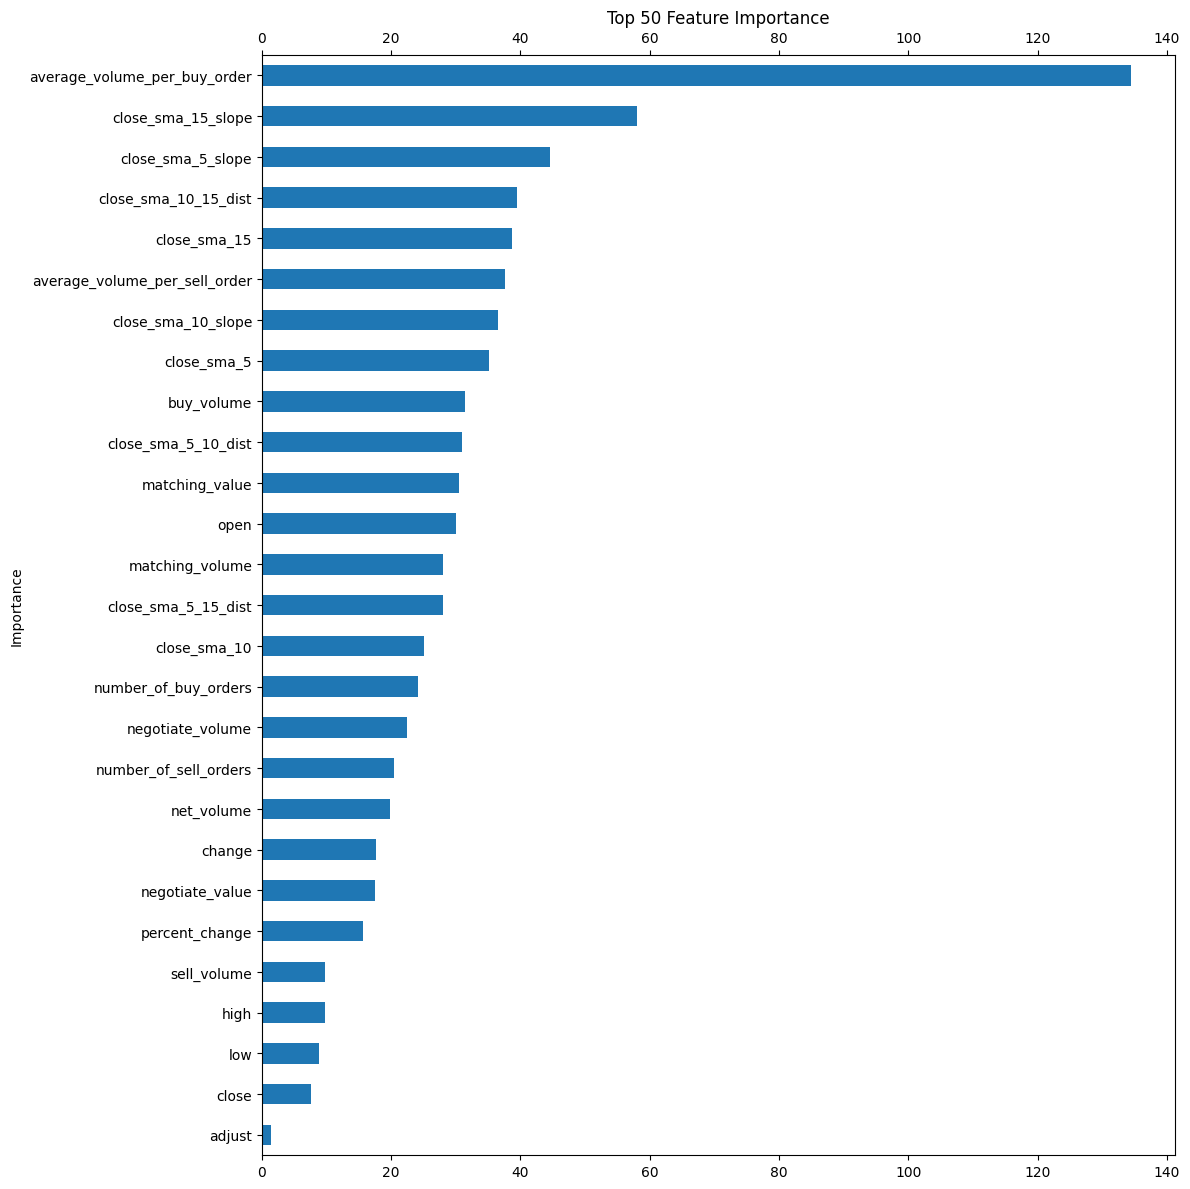

In [276]:
top_features = (
    importance_df.sort_values("importance", ascending=False)
    .head(TOP_N)
    .set_index("feature")["importance"]
).sort_values(ascending=True)

# Plot
ax = top_features.plot(kind="barh", figsize=(12, 12))

plt.title(f"Top {TOP_N} Feature Importance")
plt.ylabel("Importance")

# Show x ticks on both top and bottom
ax.xaxis.set_ticks_position("both")
ax.tick_params(axis="x", which="both", top=True, bottom=True, labeltop=True)

plt.tight_layout()
plt.show()

In [277]:
TOP_N_FEATURES = list(top_features.index)
TOP_N_FEATURES

['adjust',
 'close',
 'low',
 'high',
 'sell_volume',
 'percent_change',
 'negotiate_value',
 'change',
 'net_volume',
 'number_of_sell_orders',
 'negotiate_volume',
 'number_of_buy_orders',
 'close_sma_10',
 'close_sma_5_15_dist',
 'matching_volume',
 'open',
 'matching_value',
 'close_sma_5_10_dist',
 'buy_volume',
 'close_sma_5',
 'close_sma_10_slope',
 'average_volume_per_sell_order',
 'close_sma_15',
 'close_sma_10_15_dist',
 'close_sma_5_slope',
 'close_sma_15_slope',
 'average_volume_per_buy_order']

### Feature Correlation

Correlation Matrix:


,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,...,net_volume,close_sma_5,close_sma_5_slope,close_sma_10,close_sma_10_slope,close_sma_15,close_sma_15_slope,close_sma_5_10_dist,close_sma_5_15_dist,close_sma_10_15_dist
open,1.000000,0.999885,0.999813,0.999661,0.999661,0.025896,0.007039,0.839082,0.854228,0.663379,...,-0.173047,0.999593,0.083557,0.998773,0.119357,0.997866,0.148667,0.107775,0.130532,0.130338
high,0.999885,1.000000,0.999763,0.999814,0.999814,0.032934,0.013284,0.839587,0.854720,0.663278,...,-0.170425,0.999655,0.083813,0.998889,0.118738,0.998025,0.147821,0.105961,0.128559,0.128593
low,0.999813,0.999763,1.000000,0.999833,0.999833,0.038437,0.017264,0.836643,0.851653,0.663426,...,-0.169110,0.999392,0.091593,0.998458,0.125350,0.997504,0.153709,0.111550,0.133776,0.132244
close,0.999661,0.999814,0.999833,1.000000,1.000000,0.048144,0.025684,0.837600,0.852598,0.663426,...,-0.164789,0.999433,0.092221,0.998561,0.124959,0.997655,0.152661,0.109486,0.131546,0.130287
adjust,0.999661,0.999814,0.999833,1.000000,1.000000,0.048144,0.025684,0.837600,0.852598,0.663426,...,-0.164789,0.999433,0.092221,0.998561,0.124959,0.997655,0.152661,0.109486,0.131546,0.130287
change,0.025896,0.032934,0.038437,0.048144,0.048144,1.000000,0.893835,-0.018111,-0.018234,0.024080,...,0.345647,0.022979,0.495594,0.017898,0.358879,0.016026,0.281597,0.172715,0.143835,0.078030
percent_change,0.007039,0.013284,0.017264,0.025684,0.025684,0.893835,1.000000,-0.018740,-0.017506,0.009000,...,0.277541,0.002494,0.463406,-0.002567,0.336837,-0.004401,0.269883,0.170404,0.140689,0.074541
matching_volume,0.839082,0.839587,0.836643,0.837600,0.837600,-0.018111,-0.018740,1.000000,0.963386,0.628185,...,-0.181532,0.837699,0.095948,0.835204,0.160292,0.832476,0.200790,0.151136,0.186305,0.189296
matching_value,0.854228,0.854720,0.851653,0.852598,0.852598,-0.018234,-0.017506,0.963386,1.000000,0.570780,...,-0.186658,0.852788,0.094433,0.850303,0.160081,0.847565,0.204984,0.151980,0.187731,0.191124
negotiate_volume,0.663379,0.663278,0.663426,0.663426,0.663426,0.024080,0.009000,0.628185,0.570780,1.000000,...,-0.144325,0.663955,0.024628,0.664554,0.049080,0.664697,0.059391,0.033091,0.048205,0.056290


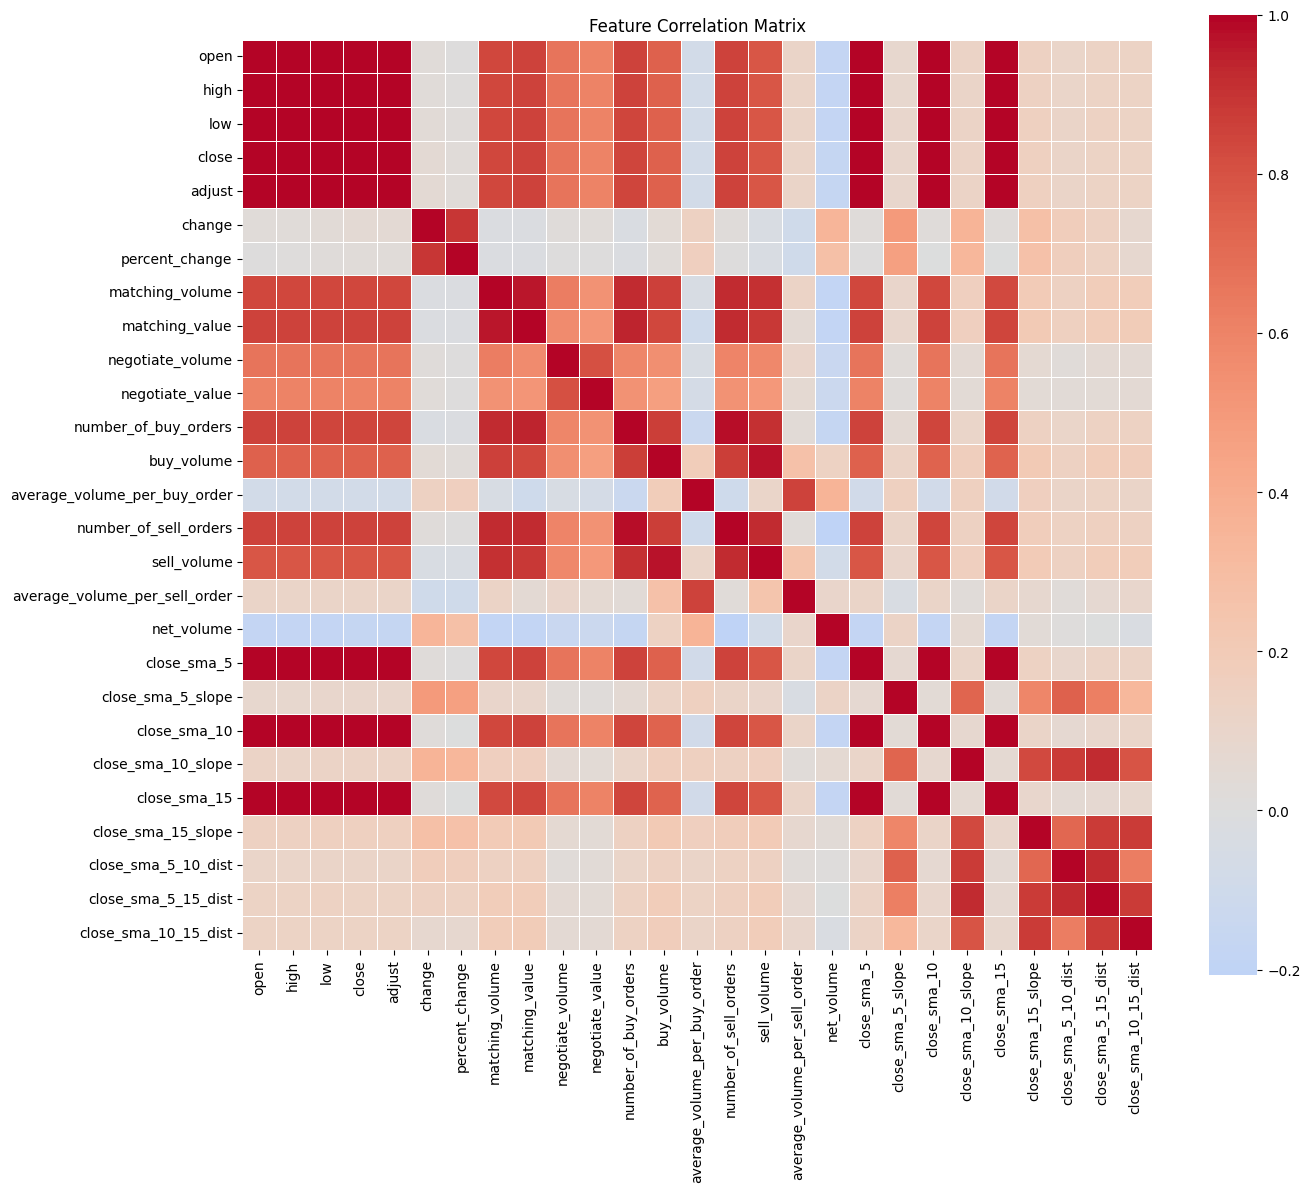

In [278]:
corr_matrix = input_df[FEATURE_COLUMNS].corr()

print("Correlation Matrix:")
display(corr_matrix)

# -----------------------------
# HEATMAP VISUALIZATION
# -----------------------------
plt.figure(figsize=(14, 12))

sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, linewidths=0.5)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### Feature Selection

In [279]:
CORR_THRESHOLD = 0.95

# Correlation matrix (absolute values)
corr_matrix = input_df[FEATURE_COLUMNS].corr().abs()

# Features sorted by importance
sorted_features = importance_df.sort_values("importance", ascending=False)[
    "feature"
].tolist()

selected_features = []
removed_features = set()

for feature in sorted_features:

    if feature in removed_features:
        continue

    selected_features.append(feature)

    # Find correlated features
    correlated = corr_matrix.index[corr_matrix[feature] > CORR_THRESHOLD].tolist()

    for corr_feature in correlated:
        if corr_feature != feature:
            removed_features.add(corr_feature)

print("Selected features:", len(selected_features))
print("Removed features:", len(removed_features))

print("\nTop kept features:")
print(selected_features[:TOP_N])

print("\nRemoved features:")
print(list(removed_features))

Selected features: 17
Removed features: 10

Top kept features:
['average_volume_per_buy_order', 'close_sma_15_slope', 'close_sma_5_slope', 'close_sma_10_15_dist', 'close_sma_15', 'average_volume_per_sell_order', 'close_sma_10_slope', 'buy_volume', 'close_sma_5_10_dist', 'matching_value', 'close_sma_5_15_dist', 'number_of_buy_orders', 'negotiate_volume', 'net_volume', 'change', 'negotiate_value', 'percent_change']

Removed features:
['low', 'open', 'close', 'sell_volume', 'matching_volume', 'number_of_sell_orders', 'close_sma_10', 'adjust', 'close_sma_5', 'high']


In [280]:
FINAL_FEATURE_COLUMNS = selected_features[:TOP_N]

print("Original feature count:", len(FEATURE_COLUMNS))
print("Final feature count:", len(FINAL_FEATURE_COLUMNS))

X_filtered = input_df[FINAL_FEATURE_COLUMNS]
X_filtered

Original feature count: 27
Final feature count: 17


,average_volume_per_buy_order,close_sma_15_slope,close_sma_5_slope,close_sma_10_15_dist,close_sma_15,average_volume_per_sell_order,close_sma_10_slope,buy_volume,close_sma_5_10_dist,matching_value,close_sma_5_15_dist,number_of_buy_orders,negotiate_volume,net_volume,change,negotiate_value,percent_change
1,1627.0,9.075000,9.075000,0.000000,649.215000,2138.0,9.075000,4.667790e+07,0.000000,1.458989e+12,0.000000,28694.0,1607090.0,13407520.0,18.150,7.962789e+10,2.840
2,1337.0,-3.501667,-3.501667,0.000000,645.713333,1570.0,-3.501667,1.933131e+07,0.000000,8.374665e+11,0.000000,14464.0,226000.0,-8782960.0,-19.580,1.209960e+10,-2.970
3,1412.0,-0.453333,-0.453333,0.000000,645.260000,1691.0,-0.453333,2.378011e+07,0.000000,7.659728e+11,0.000000,16836.0,290070.0,3433900.0,5.190,2.036917e+10,0.810
4,1281.0,0.468000,0.468000,0.000000,645.728000,1551.0,0.468000,1.703506e+07,0.000000,5.844466e+11,0.000000,13298.0,289160.0,-1970560.0,3.700,1.702626e+10,0.570
5,1392.0,-0.321333,0.732000,0.000000,645.406667,1439.0,-0.321333,1.917597e+07,1.053333,5.438243e+11,1.053333,13776.0,2266096.0,2340550.0,-3.800,1.488510e+11,-0.590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4680,2738.0,-3.113333,13.720000,-11.634667,1800.960667,3254.0,-0.495000,1.061450e+09,-0.550000,1.890820e+13,-12.184667,387678.0,27080782.0,2486986.0,10.000,9.275247e+11,0.550
4681,2689.1,-0.587667,16.017000,-8.206500,1800.373000,3185.3,2.840500,1.118916e+09,12.626500,2.002960e+13,4.420000,417356.0,25914207.0,13458978.0,17.815,8.824965e+11,0.979
4682,2672.8,0.534000,16.896000,-6.229500,1800.907000,3162.4,2.511000,1.138071e+09,27.011500,2.040340e+13,20.782000,427248.0,25525349.0,17116309.0,20.420,8.674871e+11,1.122
4683,2656.5,2.613667,9.053000,-3.774667,1803.520667,3139.5,5.068500,1.157227e+09,30.996000,2.077720e+13,27.221333,437141.0,25136491.0,20773640.0,23.025,8.524778e+11,1.265


### Roll time series

In [ ]:
input_df_rolled = roll_time_series(
    input_df[[DATE_COLUMN] + TOP_N_FEATURES + [COLUMN_ID]],
    column_id=COLUMN_ID,
    column_sort=DATE_COLUMN,
    max_timeshift=MAX_TIMESHIFT,
    min_timeshift=MIN_TIMESHIFT,
)
input_df_rolled

In [ ]:
input_df_rolled.drop(COLUMN_ID, axis=1)

### Extract features

In [ ]:
X = extract_features(
    input_df_rolled.drop(COLUMN_ID, axis=1),
    column_id="id",
    column_sort=DATE_COLUMN,
    impute_function=impute,
    default_fc_parameters=EfficientFCParameters(),
)

In [ ]:
X

In [ ]:
X = X.set_index(X.index.map(lambda x: x[1]), drop=True)
X.index.name = "last_date"
X

### Create forecast target

In [ ]:
y = (
    input_df.set_index(DATE_COLUMN)
    .sort_index()[TARGET_COLUMN]
    .shift(-FORECAST_HORIZON)
    .dropna()
)

y = pd.DataFrame(y)
y

In [ ]:
y = y[y.index.isin(X.index)]
X = X[X.index.isin(y.index)]

In [ ]:
X

In [ ]:
y

### Create train set

In [ ]:
TRAIN_RANGE[0], TRAIN_RANGE[1]

In [ ]:
X_train = X.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
X_train

In [ ]:
y_train = y.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
y_train

### Select features

In [ ]:
X_train_selected = select_features(X_train, y_train[TARGET_COLUMN])
X_train_selected

### Create validation set

In [ ]:
VALIDATION_RANGE[0], VALIDATION_RANGE[1]

In [ ]:
X_validation_selected = X.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]][
    X_train_selected.columns
]
X_validation_selected

In [ ]:
y_validation = y.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]]
y_validation

### Create test set

In [ ]:
TEST_RANGE[0], TEST_RANGE[1]

In [ ]:
X_test_selected = X.loc[TEST_RANGE[0] : TEST_RANGE[1]][X_train_selected.columns]
X_test_selected

In [ ]:
y_test = y.loc[TEST_RANGE[0] : TEST_RANGE[1]]
y_test

### Validate before scaling

In [ ]:
import numpy as np


def get_bad_columns(
    df: pd.DataFrame, variance_threshold=1e-6, range_threshold=1e6
) -> np.ndarray:
    """
    Returns indices of columns that are:
    - NaN anywhere
    - Inf anywhere
    - Near-constant (variance below threshold) → causes scaler explosion
    - Extreme range (max - min above threshold) → causes scaler explosion
    """
    col_values = df.values.astype(np.float64)

    has_nan = np.isnan(col_values).any(axis=0)
    has_inf = np.isinf(col_values).any(axis=0)

    col_range = col_values.max(axis=0) - col_values.min(axis=0)
    near_constant = col_range < variance_threshold
    extreme_range = col_range > range_threshold

    bad_mask = has_nan | has_inf | near_constant | extreme_range
    return np.where(bad_mask)[0]


# --- Apply BEFORE scaling ---

# Detect from TRAIN only (no val/test data influence)
bad_cols = get_bad_columns(X_train_selected)
good_cols = np.setdiff1d(np.arange(X_train_selected.shape[1]), bad_cols)

print(f"Removed {len(bad_cols)} bad columns, keeping {len(good_cols)}")

# Apply the same good_cols mask to all splits
X_train_clean = X_train_selected.iloc[:, good_cols]
X_val_clean = X_validation_selected.iloc[:, good_cols]
X_test_clean = X_test_selected.iloc[:, good_cols]

# Sanity check after filtering, before scaling
assert not np.isnan(
    X_train_clean.values
).any(), "NaN still present in X_train after filtering"
assert not np.isinf(
    X_train_clean.values
).any(), "Inf still present in X_train after filtering"
assert not np.isnan(
    X_val_clean.values
).any(), "NaN still present in X_val after filtering"
assert not np.isinf(
    X_val_clean.values
).any(), "Inf still present in X_val after filtering"

# Update INPUT_SIZE after filtering
INPUT_SIZE = X_train_clean.shape[1]
print(f"INPUT_SIZE after filtering: {INPUT_SIZE}")

### Create scaler

In [ ]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(X_train_clean)
y_train_scaled = y_scaler.fit_transform(y_train)

X_validation_scaled = X_scaler.transform(X_val_clean)
y_validation_scaled = y_scaler.transform(y_validation)

X_test_scaled = X_scaler.transform(X_test_clean)
y_test_scaled = y_scaler.transform(y_test)

In [ ]:
print(
    "X_train scaled range:", X_train_scaled.min(), "→", X_train_scaled.max()
)  # [0, 1]
print(
    "X_val   scaled range:", X_validation_scaled.min(), "→", X_validation_scaled.max()
)  # ~[0, 1]
print(
    "y_train scaled range:", y_train_scaled.min(), "→", y_train_scaled.max()
)  # ~[-3, 3] for StandardScaler
print(
    "y_val   scaled range:", y_validation_scaled.min(), "→", y_validation_scaled.max()
)  # can exceed this, that's fine

### Validate shape

In [ ]:
X_train_scaled.shape

In [ ]:
y_train_scaled.shape

In [ ]:
X_validation_scaled.shape

In [ ]:
y_validation_scaled.shape

In [ ]:
X_test_scaled.shape

In [ ]:
y_test_scaled.shape

### Create dataloader

In [ ]:
train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train_scaled, dtype=torch.float32),
)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
validation_dataset = TensorDataset(
    torch.tensor(X_validation_scaled, dtype=torch.float32),
    torch.tensor(y_validation_scaled, dtype=torch.float32),
)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)

In [ ]:
test_dataset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test_scaled, dtype=torch.float32),
)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

### Create model

In [ ]:
config_dto = ConfigDto(
    # Data
    notebook_name=NOTEBOOK_NAME,
    base_features=TOP_N_FEATURES,
    stock_code="vn_index",
    train_start_date=TRAIN_RANGE[0],
    train_end_date=TRAIN_RANGE[1],
    validation_start_date=VALIDATION_RANGE[0],
    validation_end_date=VALIDATION_RANGE[1],
    test_start_date=TEST_RANGE[0],
    test_end_date=TEST_RANGE[1],
    # Data Hyperparameters
    random_seed=RANDOM_SEED,
    max_lookback_window_size=MAX_TIMESHIFT,
    min_lookback_window_size=MIN_TIMESHIFT,
    forecast_window_size=FORECAST_HORIZON,
    scaler_type=ScalerType.MINMAX,
    # Model
    model_architecture=ModelAchitectureType.CNN,
    model_params=MODEL_PARAMS,
    # Training Hyperparameters
    epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    optimizer=OptimizerType.ADAM,
    loss_fn=LossFunctionType.MSE,
    patience=PATIENCE,
)

In [ ]:
class LightningCNN(L.LightningModule):

    def __init__(self, random_seed, input_size, config_dto: ConfigDto):
        super().__init__()

        L.seed_everything(seed=random_seed)

        self.input_size = int(input_size)

        if self.input_size <= 0:
            raise Exception("input_size must be greater than 0")

        self.conv = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            #  Block 2
            nn.Conv1d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            # Block 3
            nn.Conv1d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.fc = nn.Sequential(
            nn.Linear(128 * (input_size // 8), 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

        self.save_hyperparameters(asdict(config_dto))

    def forward(self, x):
        x = x.unsqueeze(1)

        x = self.conv(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        return x

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=LEARNING_RATE)

    def training_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("val_loss", loss, prog_bar=True)
        return loss

In [ ]:
model = LightningCNN(RANDOM_SEED, INPUT_SIZE, config_dto)

### Train model

In [ ]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",  # metric to watch
    patience=PATIENCE,  # epochs to wait before stopping
    mode="min",  # because lower loss is better
)

In [ ]:
import torch
from lightning.pytorch.loggers import TensorBoardLogger

torch.serialization.add_safe_globals(
    [ScalerType, ModelAchitectureType, OptimizerType, LossFunctionType]
)

# logger = TensorBoardLogger(
#     "D:/GIT/master-thesis/src/model/lightning_logs", name="", version=3
# )
# path_to_checkpoint = "D:/GIT/master-thesis/src/model/lightning_logs/version_3/checkpoints/epoch=4960-step=783838.ckpt"

logger = None
path_to_checkpoint = None

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    log_every_n_steps=1,
    callbacks=[early_stop_callback],
    logger=logger,
)

trainer.fit(
    model,
    train_dataloaders=train_dataloader,
    val_dataloaders=validation_dataloader,
    ckpt_path=path_to_checkpoint,
)

In [ ]:
y_test

In [ ]:
y_test.shape

In [ ]:
y_pred_tensor = model(torch.tensor(X_test_scaled, dtype=torch.float32))

y_pred_numpy = y_pred_tensor.detach().cpu().numpy()

# Ensure correct shape for the scaler
y_pred_numpy = y_pred_numpy.reshape(-1, 1)

# Inverse transform
y_pred_inverse = y_scaler.inverse_transform(y_pred_numpy)

# Create Pandas Dataframe
y_predict_plot = pd.DataFrame(
    y_pred_inverse.squeeze(), index=X_test_selected.index, columns=["predict"]
)

y_predict_plot

In [ ]:
plt.figure(figsize=(15, 6))
plt.title("VN INDEX - 1 Feature")

y_test.plot(ax=plt.gca(), legend="close")
y_predict_plot.plot(ax=plt.gca(), legend="predict", marker=None)

plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# Convert to numpy arrays (flatten in case they are DataFrames)
y_true = y_test.values.flatten()
y_pred = y_predict_plot.values.flatten()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1️⃣ MSE (Mean Squared Error)
mse = mean_squared_error(y_true, y_pred)

# 2️⃣ MAPE (Mean Absolute Percentage Error)
# Avoid division by zero
mape = np.mean(np.where(y_true == 0, 0, np.abs((y_true - y_pred) / y_true))) * 100

# 3️⃣ RMSSE (Root Mean Squared Scaled Error)
# RMSSE needs scaling by naive forecast (lag-1)
denominator = np.mean(np.diff(y_true) ** 2)
rmsse = np.sqrt(mse / denominator)

# 4️⃣ SMAPE (Symmetric MAPE)
denom = np.abs(y_true) + np.abs(y_pred)
smape = np.mean(np.where(denom == 0, 0, 2 * np.abs(y_pred - y_true) / denom)) * 100

# 5️⃣ WAPE (Weighted Absolute Percentage Error)
wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

# 6️⃣ R² (Coefficient of Determination)
r2 = r2_score(y_true, y_pred)

# 7️⃣ Adjusted R²
# Requires number of samples (n) and features (p)
n = len(y_true)
p = X_test_scaled.shape[1]  # make sure X_test exists

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# -----------------------
# Print results
# -----------------------

print(f"MSE: {mse:.4f}")
print(f"MAPE: {mape:.4f} %")
print(f"RMSSE: {rmsse:.4f}")
print(f"SMAPE: {smape:.4f} %")
print(f"WAPE: {wape:.4f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

### Predict

In [ ]:
# Get last row and keep 2D shape
last_row = X_test_scaled[-1:]
last_row.shape

In [ ]:
# Convert to tensor
last_row_tensor = torch.tensor(last_row, dtype=torch.float32)

with torch.no_grad():
    y_pred = model(last_row_tensor)

y_pred_inverse = y_scaler.inverse_transform(y_pred.cpu().numpy().reshape(-1, 1))

y_predict = pd.DataFrame(
    y_pred_inverse, index=[X_test_selected.index[-1]], columns=["predict"]
)

y_predict.squeeze()

### Save data

In [ ]:
import os
import sys
import pickle
import ipynbname
import json
from torch.utils.tensorboard import SummaryWriter

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from utils.utils import get_current_run_path, save_prediction_figure

result_folder = get_current_run_path()

NB_NAME = ipynbname.name()

# -----------------------
# Save model
# -----------------------
pickle_path = os.path.join(result_folder, "model.pkl")
with open(pickle_path, "wb") as f:
    pickle.dump(model, f)


# -----------------------
# Save metrics to JSON
# -----------------------
result_path = os.path.join(result_folder, "result.json")

results = {
    "MSE": mse,
    "MAPE": mape,
    "RMSSE": rmsse,
    "SMAPE": smape,
    "WAPE": wape,
    "R2": r2,
    "Adjusted_R2": adj_r2,
}

with open(result_path, "w") as f:
    json.dump(results, f, indent=4)

# -----------------------
# Save prediction figure
# -----------------------
fig_path = os.path.join(result_folder, f"{NB_NAME}.jpg")

save_prediction_figure(
    y_test=y_test, y_predict=y_predict_plot, save_path=fig_path, title=f"{NB_NAME}"
)

writer = SummaryWriter(result_folder)

writer.add_scalar("Metrics/MSE", mse, 0)
writer.add_scalar("Metrics/MAPE", mape, 0)
writer.add_scalar("Metrics/RMSSE", rmsse, 0)

writer.close()

print(f"Saved results to: {result_folder}")

In [ ]:
from win11toast import toast
import ipynbname

NB_NAME = ipynbname.name()

# Simple notification
toast("Completed training", f"Model '{NB_NAME}' trained successfully.")